In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/processed/day4_risk_scored_data.csv")
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country', 'missing_customer_flag',
       'Revenue', 'zero_price_flag', 'is_return', 'return_risk_flag',
       'risk_score', 'risk_category'],
      dtype='object')

**1. Risk Category Distribution**

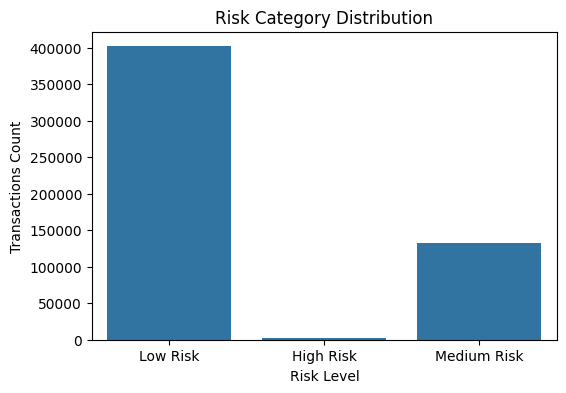

In [4]:
plt.figure(figsize= (6,4))

sns.countplot(x='risk_category', data=df)
plt.title('Risk Category Distribution')
plt.xlabel('Risk Level')
plt.ylabel('Transactions Count')
plt.show()

**2. Risk by Country**

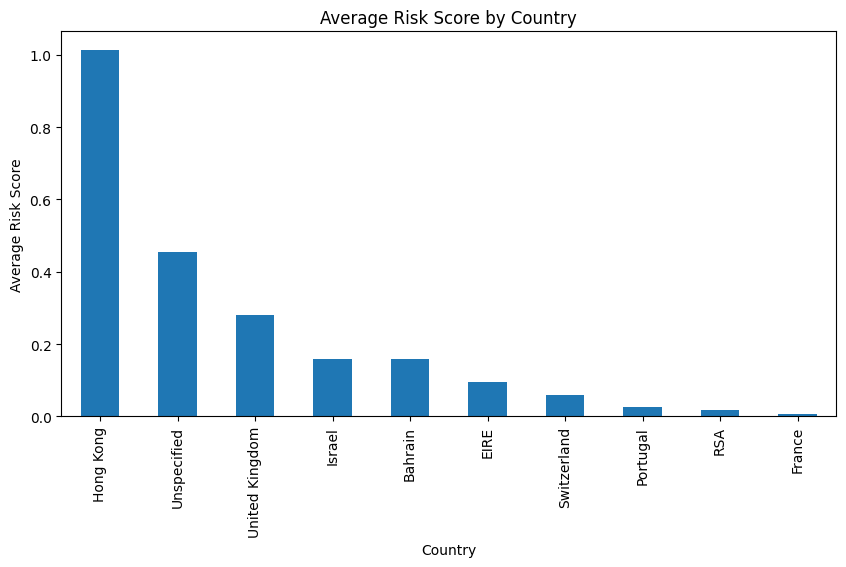

In [5]:
country_risk = df.groupby('Country')['risk_score'].mean().sort_values(ascending = False).head(10)
plt.figure(figsize = (10,5))
country_risk.plot(kind = 'bar')

plt.title("Average Risk Score by Country")
plt.ylabel("Average Risk Score")

plt.show()

**3. Zero Price Transactions**

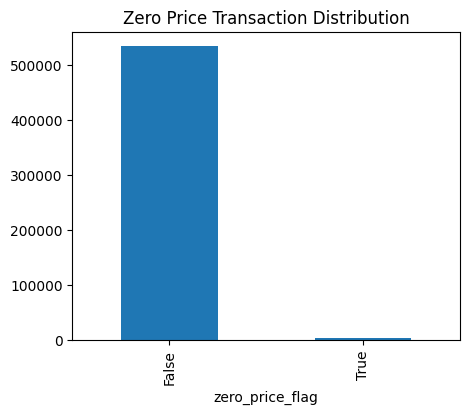

In [6]:
zero_price_counts = df['zero_price_flag'].value_counts()

plt.figure(figsize=(5,4))

zero_price_counts.plot(kind='bar')

plt.title("Zero Price Transaction Distribution")

plt.show()

**4. Return Risk Analysis**

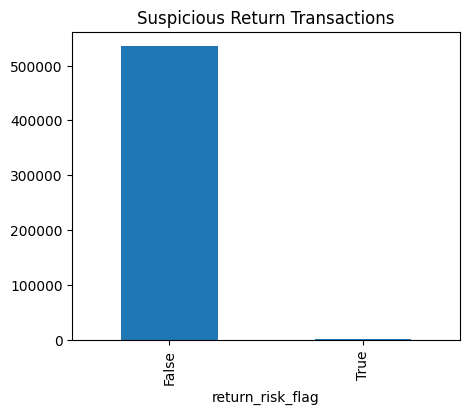

In [7]:
return_counts = df['return_risk_flag'].value_counts()

plt.figure(figsize=(5,4))

return_counts.plot(kind='bar')

plt.title("Suspicious Return Transactions")

plt.show()

**5. Revenue vs Risk Score**

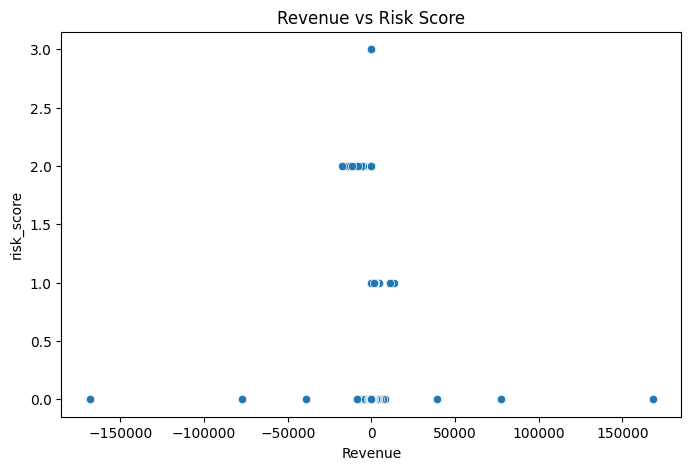

In [8]:
plt.figure(figsize=(8,5))

sns.scatterplot(x='Revenue', y='risk_score', data=df)

plt.title("Revenue vs Risk Score")

plt.show()

In [9]:
high_risk = df[df['risk_category'] == "High Risk"]

high_risk[['InvoiceNo', 'Revenue', 'Country', 'risk_score']].head(10)

,InvoiceNo,Revenue,Country,risk_score
605,536414,0.0,United Kingdom,2
1934,536545,0.0,United Kingdom,2
1935,536546,0.0,United Kingdom,2
1936,536547,0.0,United Kingdom,2
1951,536549,0.0,United Kingdom,2
1952,536550,0.0,United Kingdom,2
1984,536552,0.0,United Kingdom,2
1985,536553,0.0,United Kingdom,2
1986,536554,0.0,United Kingdom,2
2362,536589,-0.0,United Kingdom,3


In [10]:
df.to_csv("../dashboard/dashboard_data.csv", index=False)

## 📌 Day 5 Summary

Audit-focused visualizations were created to analyze transaction risk patterns and support decision-making.

Key visual insights included:
- Distribution of Low, Medium, and High risk transactions
- Country-wise risk concentration
- Zero-price transaction analysis
- Suspicious return behavior
- Relationship between revenue and risk score

These visualizations improve interpretability of the audit model and help prioritize audit attention effectively.